Original sources shape: (200, 2)
Mixed signals shape: (200, 2)


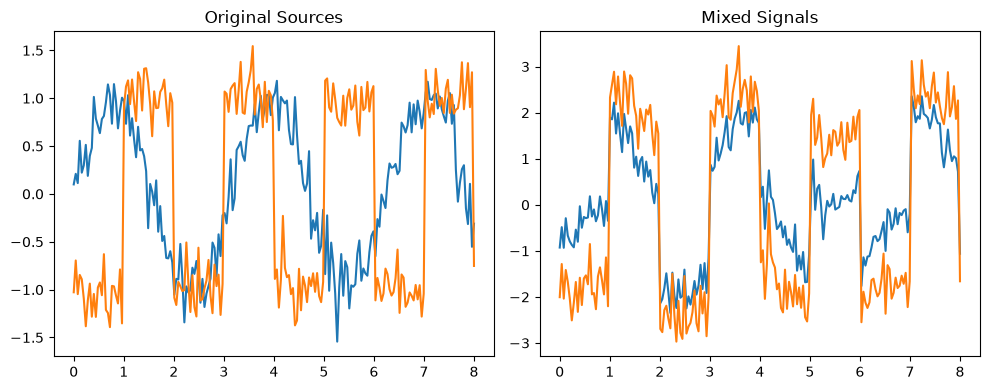

Recovered sources shape (ICA): (200, 2)


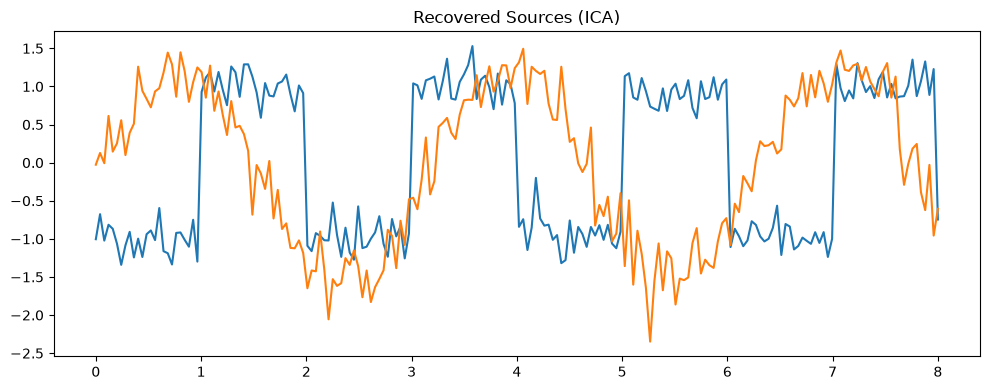


First 5 rows of mixed data:
 [[-0.92831003 -2.00563431]
 [-0.48554091 -1.2858615 ]
 [-0.93354616 -2.03701417]
 [-0.29179657 -1.41566787]
 [-0.66929031 -1.67187714]]

First 5 rows of recovered sources (ICA):
 [[-1.004367   -0.02671752]
 [-0.67616241  0.12704744]
 [-1.02276323 -0.00699652]
 [-0.81485074  0.61325287]
 [-0.86778537  0.14547221]]


In [1]:
from sklearn.decomposition import FastICA
import numpy as np
import matplotlib.pyplot as plt # Added for visualization

# 1. Create some sample independent source signals
np.random.seed(42) # for reproducibility
n_samples = 200
time = np.linspace(0, 8, n_samples)

# Source 1: Sine wave
s1 = np.sin(2 * time)
# Source 2: Sawtooth wave
s2 = np.sign(np.mod(time, 2) - 1)

# Combine sources
S = np.c_[s1, s2]
# Add some noise
S += 0.2 * np.random.normal(size=S.shape)

print("Original sources shape:", S.shape) # Output: (200, 2)

# 2. Mix the sources linearly (This is the observed data)
A = np.array([[1, 1], [0.5, 2]]) # Mixing matrix
X_mixed = S @ A.T # Perform the mixing

print("Mixed signals shape:", X_mixed.shape) # Output: (200, 2)


# Optional: Visualize original and mixed signals
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(time, S)
plt.title("Original Sources")
plt.subplot(1, 2, 2)
plt.plot(time, X_mixed)
plt.title("Mixed Signals")
plt.tight_layout()
plt.show()


# 3. Apply ICA to try and recover the independent sources
# Choose n_components equal to the estimated number of sources
ica = FastICA(n_components=2, random_state=42) # n_components should match number of sources
recovered_sources = ica.fit_transform(X_mixed) # Recover the sources

print("Recovered sources shape (ICA):", recovered_sources.shape) # Output: (200, 2)

# Optional: Visualize recovered signals
# Note: ICA recovers the sources up to scaling and sign.
# The order of recovered sources might also be different from the original.
plt.figure(figsize=(10, 4))
plt.plot(time, recovered_sources)
plt.title("Recovered Sources (ICA)")
plt.tight_layout()
plt.show()

# The 'recovered_sources' variable contains the statistically independent components extracted by ICA.
print("\nFirst 5 rows of mixed data:\n", X_mixed[:5])
print("\nFirst 5 rows of recovered sources (ICA):\n", recovered_sources[:5])

# You would use 'recovered_sources' as features for subsequent analysis or modeling.